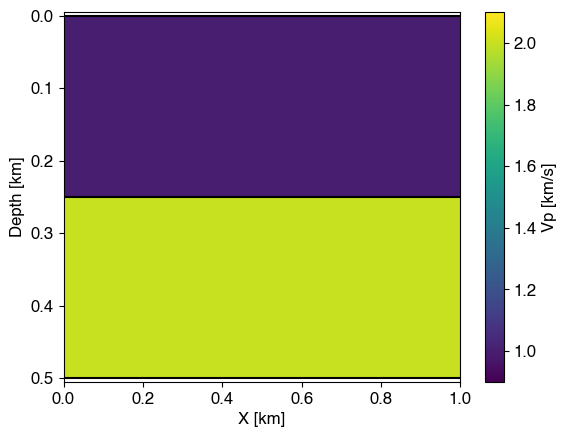

In [1]:
import numpy as np
from frequensolve import *

project_path = "./scratch/ex_04/"
project = Project(name           = "project",
                  pretty_name    = "DAS Simulation",
                  path           = project_path,
                  load_if_exists = False)

sim = SeismicSimulation(name      = "simulation_1",
                        physics   = "elastic",
                        dimension = 2)
project += sim

# New 2D layered model over interval x in [0,1]
model = LayeredModel(dimension = 2, x_limits = [0.0, 1.0])

model.add_surface(name = "top", z = 0.0)

model.add_layer(                    # Layer 1
   name = "layer_1",
   properties = { "Vp" : 1.0,
                  "Qp" : 100.0,
                  "Vs" : 0.5,
                  "Qs" : 100.0,
                  "Rho": 1.0 }
)
model.add_surface(name = "interface", z = 0.25)

model.add_layer(                    # Layer 2 
   name = "layer_2",
   properties = { "Vp" : 2.0,
                  "Qp" : 100.0,
                  "Vs" : 1.0,
                  "Qs" : 100.0,
                  "Rho": 1.0 }
)
model.add_surface(name = "bottom", z = 0.5)

model.plot("Vp")
sim += model

# Define a Hex mesh generator
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(min_epw = 2.0,
                   adapt_sources = 2)

# New boundery condition manager
BCs = BoundaryConditionManager(label_type = "geometric")

# Free surface BC
BCs += BoundaryCondition(name       = "free_surface",
                         kind       = "neumann",
                         boundaries = ["z_min"])

# PML boundary condition
BCs += BoundaryCondition(name = "pml",
                         kind = "pml",
                         boundaries = ["x_min", "x_max", "z_max"],
                         pml_wavelengths = 2.0,
                         pml_exponent    = 3.0,
                         pml_constant    = 20.0)
sim += BCs

In [2]:
acq = Acquisition()

# --- Source ---
acq.add_source_group(kind   = "vector",
                     coords = [[0.5, 0.0]],
                     direction = [0.0, 1.0])

# -- Receivers ---
# Surface hydrophones
hydrophone = ReceiverNode(name = "hydrophone")
hydrophone.add_component("u_z","displacement",[0.0, 1.0])

coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 1001)]
acq.add_receiver_group(name   = "surface_hydrophones",
                       device = hydrophone,
                       coords = coords,
                       frame  = "reference")

# downhole DAS
das = ReceiverFiber(name    = "fiber",
                    L_gauge = 0.01,
                    n_gauge = 100,
                    radius  = 0.001,
                    pitch   = 0.005)
das.add_component("eps_tt", "strain")

coords = [ [0.25, z] for z in np.linspace(0.0, 0.5, 101)]
acq.add_receiver_group(name   = "well_das",
                       device = das,
                       coords = coords,
                       frame  = "physical")

sim += acq

method = Discretization(order = 4)
sim += method

out = OutputManager()
out += ParaviewOutput(name = "simple", fields = ["pressure", "displacement"], upscale = 1)
out += WavefieldOutput(name = "wavefield", fields = ["primary"])
sim += out

project.save()

'/Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_04/project.json'

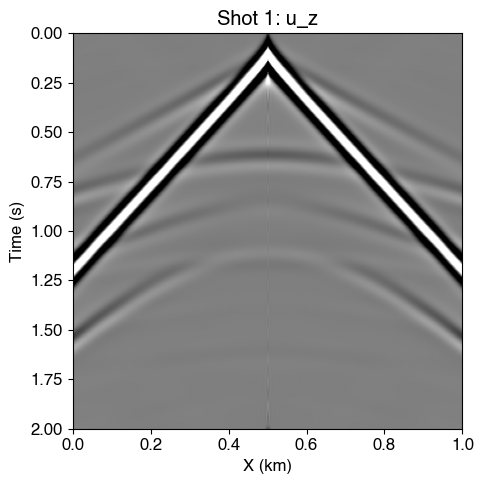

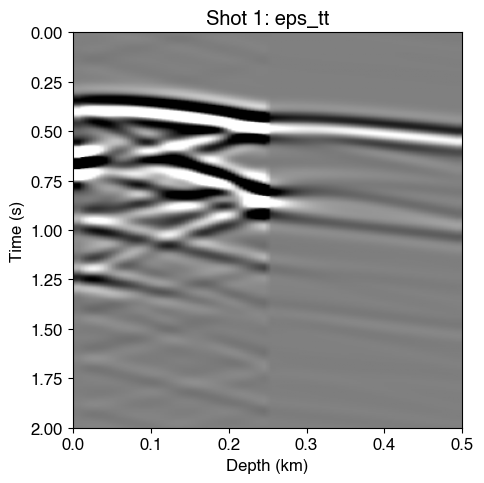

In [ ]:
project.site = LocalSite()
project.transfer()

# Create and submit frequency domain job
job = TimeDomainJob(name = "fd_job",
                    simulation = sim,
                    f_min = 1.0,
                    f_max = 20.0,
                    T_max = 2.0)

results = project.submit_job(job)

# # Skips simulation if you already have results
# results = job.records

record_db = project.get_records(results)
up = 4
for record in record_db:
    wavelet = RickerWavelet(f0 = 6.0, times = record.times(upscale = up), offset = 5)
    shot = record.read_TD(wavelet, upscale = up)
    A = 2*np.std(np.abs(shot.data))
    plot_gather(shot, A = A)